In [1]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.93'


/users/PAS2905/coraalbers/.conda/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pickle

Use pickle to save variant score objects!

```python
# Assuming your list of AnnData objects is named adata_list
with open('my_anndata_list.pkl', 'wb') as f:
    pickle.dump(adata_list, f)
```
```python
# To load it back later:
with open('my_anndata_list.pkl', 'rb') as f:
    loaded_adata_list = pickle.load(f)
```

In [3]:
# model = dna_model.create_from_huggingface(
#     'all_folds',
#     organism_settings={
#         dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings(
#             fasta_path='hg38.fa'
#         ),
#         # Mandatory dummy entry so the model knows how to load the weights
#         dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings()
#     }
# )

In [8]:
# gtf = pd.read_feather(
#     'https://storage.googleapis.com/alphagenome/reference/gencode/'
#     'hg38/gencode.v46.annotation.gtf.gz.feather')

## ism
https://colab.research.google.com/github/google-deepmind/alphagenome/blob/main/colabs/quick_start.ipynb#scrollTo=O93kx8lckYVu

```bash
wget https://storage.googleapis.com/alphagenome/reference/gencode/hg38/gencode.v46.annotation.gtf.gz.feather
wget https://storage.googleapis.com/alphagenome/reference/gencode/hg38/gencode.v46.splice_sites_starts.feather
wget https://storage.googleapis.com/alphagenome/reference/gencode/hg38/gencode.v46.splice_sites_ends.feather
```

In [9]:
model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path='hg38.fa', 
            gtf_feather_path='ag_data/gencode.v46.annotation.gtf.gz.feather', 
            splice_site_starts_feather_path='ag_data/gencode.v46.splice_sites_starts.feather', 
            splice_site_ends_feather_path='ag_data/gencode.v46.splice_sites_ends.feather', 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )







Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 8086.70it/s]


We define an `ism_interval`, which is a relatively small region of DNA that we
want to systematically mutate. We also define the `sequence_interval`, which is
the contextual interval the model will use when making predictions for each
variant.


LMNA coords:
- chr1
- start: 156_114_711
- stop: 156_140_081

In [11]:
# dnase_variant_scorer = variant_scorers.CenterMaskScorer(
#     requested_output=dna_client.OutputType.RNA_SEQ,
#     width=501,
#     aggregation_type=variant_scorers.AggregationType.DIFF_MEAN,
# )

In [12]:
# # bag3 coords
# #target_start = 119640000 #upstream 10kb before high activity place start 
# #target_start = 119650800 
# target_start = 119661600 
# target_end = 119672500 #downstream 10kb after high activity place end


# #testing for two other positions 
# target_start = 119672656 
# target_end = 119672660

In [14]:
print(variant_scorers.RECOMMENDED_VARIANT_SCORERS)

immutabledict({'ATAC': CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM), 'CONTACT_MAPS': ContactMapScorer(), 'DNASE': CenterMaskScorer(requested_output=DNASE, width=501, aggregation_type=DIFF_LOG2_SUM), 'CHIP_TF': CenterMaskScorer(requested_output=CHIP_TF, width=501, aggregation_type=DIFF_LOG2_SUM), 'CHIP_HISTONE': CenterMaskScorer(requested_output=CHIP_HISTONE, width=2001, aggregation_type=DIFF_LOG2_SUM), 'CAGE': CenterMaskScorer(requested_output=CAGE, width=501, aggregation_type=DIFF_LOG2_SUM), 'PROCAP': CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=DIFF_LOG2_SUM), 'RNA_SEQ': GeneMaskLFCScorer(requested_output=RNA_SEQ), 'RNA_SEQ_ACTIVE': GeneMaskActiveScorer(requested_output=RNA_SEQ), 'SPLICE_SITES': GeneMaskSplicingScorer(requested_output=SPLICE_SITES, width=None), 'SPLICE_SITE_USAGE': GeneMaskSplicingScorer(requested_output=SPLICE_SITE_USAGE, width=None), 'SPLICE_JUNCTIONS': SpliceJunctionScorer(), 'POLYADENYLATION': Polyade

In [19]:
# DNA sequence to use as context when making predictions.

target_start = 156_106_711
target_end = 156_107_711

#reg1: 156_104_711, 156_105_711
#reg2: 156_105_711, 156_106_711


# region_num,target_start,target_end
# 1,156_104_711,156_114_711
# 2,156_094_711,156_104_711
# 3,156084711,156094711
# 4,156074711,156084711
# 5,156064711,156074711
# 6,156140081,156150081
# 7,156150081,156160081
# 8,156160081,156170081
# 9,156170081,156180081
# 10,156180081,156190081

# region coords: 156064711-156190081



## center 100kb region around 25 kb region (on 3' end) before LMNA gene start
# sequence_interval = genome.Interval('chr1', target_start, target_end)
# sequence_interval = sequence_interval.resize(dna_client.SEQUENCE_LENGTH_100KB)

# Mutate all bases in the central x-base region of the sequence_interval.
# ism_interval = sequence_interval.resize(1000)

In [20]:
ism_interval = genome.Interval('chr1', target_start, target_end) 
sequence_interval = ism_interval.resize(32768) 
lmna_context = ism_interval.resize(dna_client.SEQUENCE_LENGTH_100KB)

sj_variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_JUNCTIONS']

scorers = [
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_SITES'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_SITE_USAGE'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_JUNCTIONS'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['ATAC'],
]


variant_scores = model.score_ism_variants( 
    interval=lmna_context, 
    ism_interval=ism_interval, 
    variant_scorers=scorers, 
    organism=dna_client.Organism.HOMO_SAPIENS, 
)

# variant_scores.to_pickle("variant_scores_testregion.pkl")
# with open('lmna_ism_pre_region3_100kb.pkl', 'wb') as f:
#     pickle.dump(variant_scores, f)








100%|██████████| 3000/3000 [36:40<00:00,  1.36it/s]


In [36]:
import anndata
with open('lmna_ism_pre_region3_100kb.pkl', 'rb') as f:
    variant_scores = pickle.load(f)
    
variant_scores = anndata.AnnData(X=np.array(variant_scores, dtype=object))


In [38]:
variant_scores



AnnData object with n_obs × n_vars = 3000 × 5

In [41]:
def extract_splice_scores_fixed(adata): 
    var = adata.var 
    mask = (var['ontology_curie'] == 'UBERON:0000948') & (var['Assay title'] == 'total RNA-seq') 
    if adata.X.shape[0] == 0: 
        return float('nan') 
    values = adata.X[0, mask] 
    if values.size == 0: 
        return float('nan') 
    return float(values.max())
    
rows = [] 
for vs in variant_scores: 
    print(vs.uns)
    variant = vs[0].uns['variant'] 
    score = extract_splice_scores_fixed(vs[0]) 
    rows.append({ 
        'position': variant.position, 
        'ref': variant.reference_bases, 
        'alt': variant.alternate_bases, 
        'delta_score': score, 
    })

ism_df = pd.DataFrame(rows) 
ism_df.to_csv('lmna_ism_pre_region1_100kb.csv', index=False) 
print(f"Total rows: {len(ism_df)}") 
print(f"Non-NaN: {ism_df['delta_score'].notna().sum()}") 
print(f"NaN: {ism_df['delta_score'].isna().sum()}") 
print("Done!")

{}


KeyError: 'variant'

AttributeError: 'AnnData' object has no attribute 'ndim'

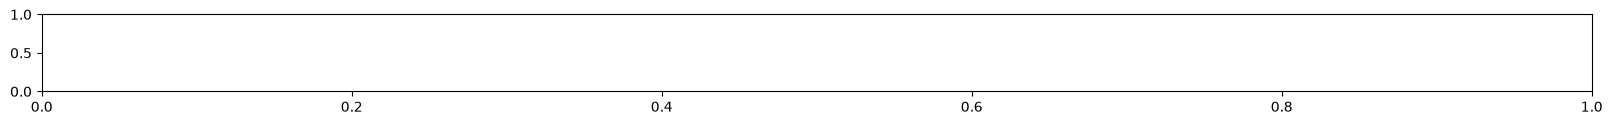

In [42]:
plot_components.plot(
    components=[
        plot_components.SeqLogo(variant_scores, ism_interval,fig_height=1.0)],
    interval=lmna_context)




plt.show()

In [38]:
sequence_length = 10
alphabet_size = 4
letter_heights = np.random.uniform(-1, 1, size=(sequence_length, alphabet_size))
letter_heights

array([[-0.55877232, -0.23445496, -0.61147025, -0.93074729],
       [-0.96133255, -0.23672783,  0.9564939 ,  0.32125823],
       [-0.14090641, -0.46659168, -0.98110363, -0.80112764],
       [-0.01118629, -0.05993273,  0.8903508 , -0.31385758],
       [ 0.85844264, -0.7893174 ,  0.33358695, -0.57212224],
       [ 0.77260375, -0.0218828 , -0.08490034,  0.74395828],
       [-0.78171185, -0.55436348, -0.01561531, -0.4917321 ],
       [ 0.21067214, -0.8370833 , -0.07987844, -0.52056349],
       [ 0.16009662, -0.40901744, -0.72067398, -0.84319907],
       [-0.8821553 ,  0.08051831, -0.19836117, -0.89120109]])

In [3]:
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

#variant stuff
variant_to_test = "chr10:119150004:C>T"
bag3_variant_string = variant_to_test
bag3_variant = genome.Variant.from_str(bag3_variant_string)
bag3_interval = gene_annotation.get_gene_interval(gtf, gene_symbol='BAG3')
bag3_interval = bag3_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

In [6]:
tissues = [
'UBERON:0001134' # This is the Uberon Ontology ID for Skeletal muscle.
#Can also do more than one tissue at once
]
output = model.predict_variant(
    interval = bag3_interval,
    variant=bag3_variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ], #We want to specifically look at BAG3 RNA
    ontology_terms= tissues
)
transcripts = transcript_extractor.extract(bag3_interval)

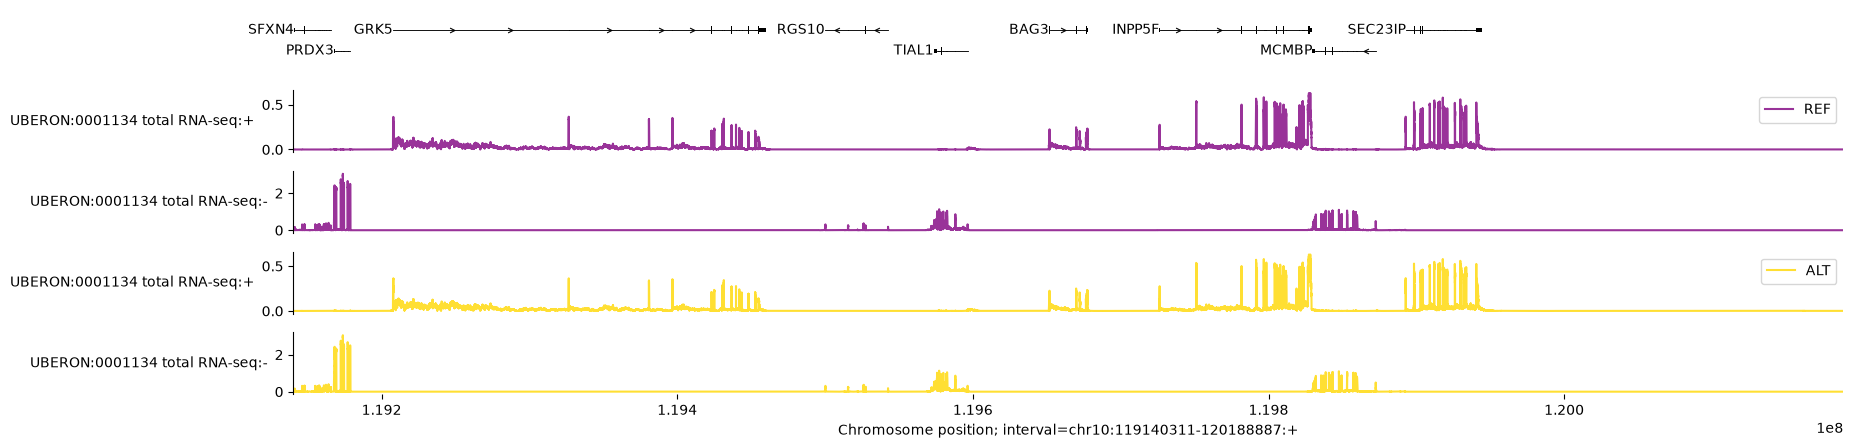

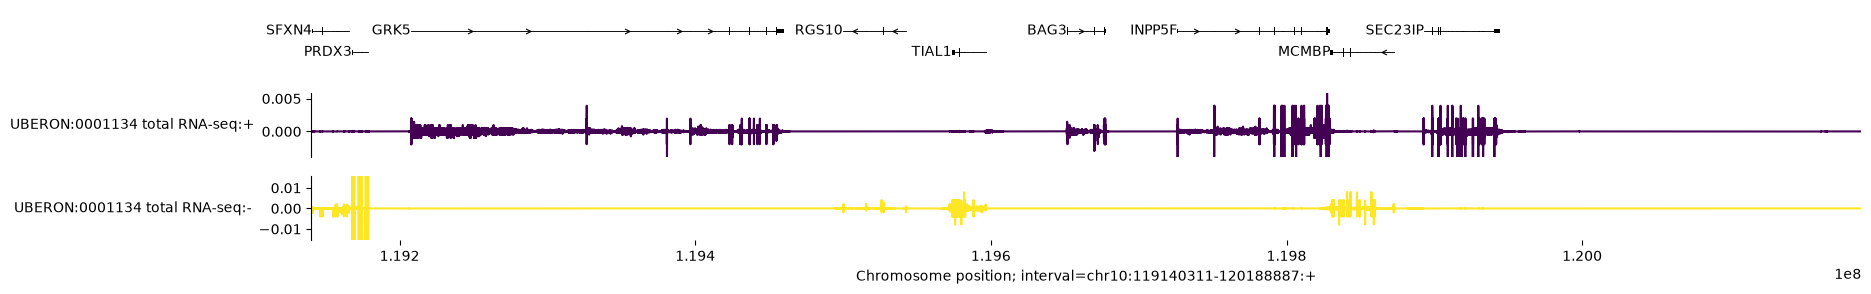

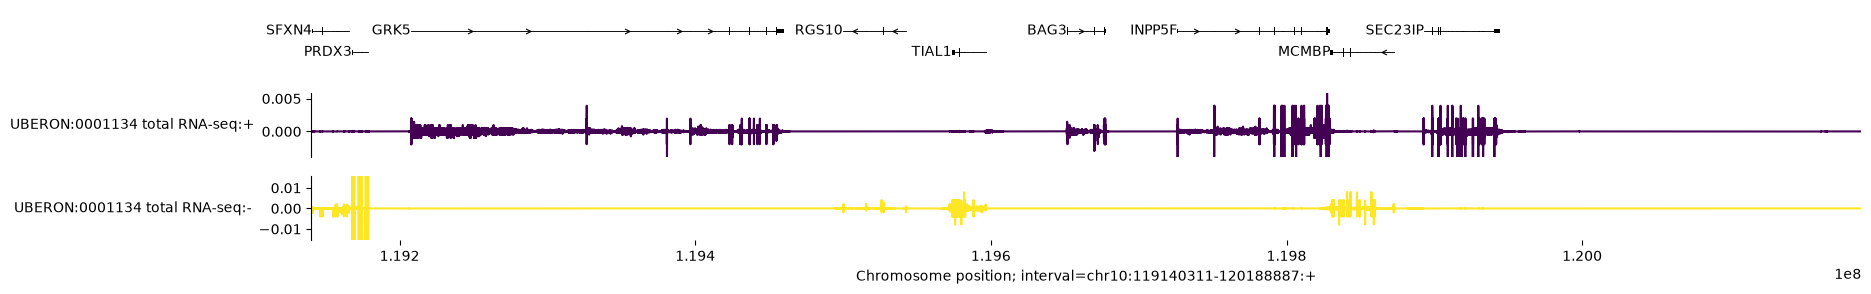

In [7]:
ref_color = {'REF':'purple'}
alt_color = {'ALT':'gold'}

plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.OverlaidTracks(
            tdata={
                'REF': output.alternate.rna_seq,#.filter_to_positive_strand(),
            }, colors = ref_color),
        plot_components.OverlaidTracks(
            tdata={
                'ALT': output.reference.rna_seq,
            }, colors = alt_color)
    ],
    interval=bag3_interval,

)

plt.show()
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.Tracks(tdata=output.alternate.rna_seq-output.reference.rna_seq)],
    interval=bag3_interval,
)

In [9]:
#target_start = 119640000 #upstream 10kb before high activity place start
#target_start = 119650800
target_start = 119661600
target_end = 119672500 #downstream 10kb after high activity place end
#testing for two other positions
target_start = 119672656
target_end = 119672660
ism_interval = genome.Interval('chr10', target_start, target_end)
sequence_interval = ism_interval.resize(32768)
bag3_context = ism_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

In [10]:
sj_variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_JUNCTIONS']
variant_scores = model.score_ism_variants(
    interval = sequence_interval,
    ism_interval=ism_interval,
    variant_scorers=[sj_variant_scorer],
    organism=dna_client.Organism.HOMO_SAPIENS,
)

  0%|          | 0/12 [00:00<?, ?it/s]


ValueError: Scorer 'BaseVariantScorer.SPLICE_JUNCTION' is missing for organism.name='HOMO_SAPIENS'. This may be due to a missing variant scorer metadata.

In [8]:
def extract_splice_scores_fixed(adata):
    var = adata.var
    mask = (var['ontology_curie'] == 'UBERON:0000948') & \
    (var['Assay title'] == 'total RNA-seq')
    if adata.X.shape[0] == 0:
        return float('nan')
    values = adata.X[0, mask]
    if values.size == 0:
        return float('nan')
    return float(values.max())